# F1 Race Analytics — 02: Data Cleaning & Exploratory Analysis
**Input:** Raw CSVs from `data/raw/`  
**Output:** Cleaned, feature-engineered DataFrames saved to `data/processed/`  
**Key features engineered:** `position_delta`, `dnf_flag`, `podium_flag`, `consistency_score`, `pole_converted`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../assets', exist_ok=True)

# Load raw data
df_results     = pd.read_csv('../data/raw/race_results.csv')
df_qualifying  = pd.read_csv('../data/raw/qualifying.csv')
df_pitstops    = pd.read_csv('../data/raw/pit_stops.csv')
df_constructors = pd.read_csv('../data/raw/constructor_standings.csv')

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('Data loaded.')
print(f'Race results: {df_results.shape}  |  Qualifying: {df_qualifying.shape}  |  Pit stops: {df_pitstops.shape}')

Data loaded.
Race results: (2979, 17)  |  Qualifying: (2976, 10)  |  Pit stops: (5119, 7)


## 1. Clean Race Results + Feature Engineering

In [ ]:
df = df_results.copy()
df['date'] = pd.to_datetime(df['date'])

# DNF: didn't finish (status not 'Finished' or '+X Laps')
df['dnf_flag'] = ~df['status'].str.contains('Finished|Lap', na=False)

# Podium: finished in top 3
df['podium_flag'] = df['finish_position'] <= 3

# Win flag
df['win_flag'] = df['finish_position'] == 1

# Position delta: negative = lost positions, positive = gained positions
df['position_delta'] = df['grid_position'] - df['finish_position']

# Drop rows where both grid and finish are null (data gaps)
df = df.dropna(subset=['finish_position'])

print(f'Cleaned results: {df.shape[0]} rows')
print(f'DNFs: {df["dnf_flag"].sum()} ({df["dnf_flag"].mean()*100:.1f}% of all race entries)')
print(f'Null check:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
df.head(3)

Cleaned results: 2979 rows
DNFs: 455 (15.3% of all race entries)
Null check:
grid_position        45
fastest_lap_rank    118
fastest_lap_time    118
position_delta       45
dtype: int64


,season,round,race_name,circuit,country,date,driver_id,driver_name,nationality,constructor,...,finish_position,points,laps_completed,status,fastest_lap_rank,fastest_lap_time,dnf_flag,podium_flag,win_flag,position_delta
0,2018,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Australia,2018-03-25,vettel,Sebastian Vettel,German,Ferrari,...,1,25.0,58,Finished,4.0,1:26.469,False,True,True,2.0
1,2018,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Australia,2018-03-25,hamilton,Lewis Hamilton,British,Mercedes,...,2,18.0,58,Finished,3.0,1:26.444,False,True,False,-1.0
2,2018,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Australia,2018-03-25,raikkonen,Kimi Räikkönen,Finnish,Ferrari,...,3,15.0,58,Finished,2.0,1:26.373,False,True,False,-1.0


In [3]:
# Driver consistency score per season:
# (podium_rate - dnf_rate) — higher is better
driver_season = df.groupby(['season', 'driver_name']).agg(
    races=('round', 'count'),
    wins=('win_flag', 'sum'),
    podiums=('podium_flag', 'sum'),
    dnfs=('dnf_flag', 'sum'),
    total_points=('points', 'sum')
).reset_index()

driver_season['win_rate']    = driver_season['wins']    / driver_season['races']
driver_season['podium_rate'] = driver_season['podiums'] / driver_season['races']
driver_season['dnf_rate']    = driver_season['dnfs']    / driver_season['races']
driver_season['consistency_score'] = (driver_season['podium_rate'] - driver_season['dnf_rate']).round(3)

driver_season.to_csv('../data/processed/driver_season_stats.csv', index=False)
print('Driver season stats saved.')
driver_season.sort_values('consistency_score', ascending=False).head(10)

Driver season stats saved.


,season,driver_name,races,wins,podiums,dnfs,total_points,win_rate,podium_rate,dnf_rate,consistency_score
120,2023,Max Verstappen,22,19,21,0,530.0,0.863636,0.954545,0.000000,0.955
53,2020,Lewis Hamilton,16,11,14,0,347.0,0.687500,0.875000,0.000000,0.875
31,2019,Lewis Hamilton,21,11,17,0,413.0,0.523810,0.809524,0.000000,0.810
9,2018,Lewis Hamilton,21,11,17,1,408.0,0.523810,0.809524,0.047619,0.762
73,2021,Lewis Hamilton,22,8,17,1,385.5,0.363636,0.772727,0.045455,0.727
96,2022,Max Verstappen,22,15,17,2,433.0,0.681818,0.772727,0.090909,0.682
74,2021,Max Verstappen,22,10,18,3,388.5,0.454545,0.818182,0.136364,0.682
39,2019,Valtteri Bottas,21,4,15,2,326.0,0.190476,0.714286,0.095238,0.619
62,2020,Valtteri Bottas,17,2,11,1,223.0,0.117647,0.647059,0.058824,0.588
144,2024,Max Verstappen,24,9,14,1,399.0,0.375000,0.583333,0.041667,0.542


In [4]:
# Merge qualifying with race results to compute pole conversion
df_pole = df_qualifying[df_qualifying['qualifying_position'] == 1][['season','round','driver_id','driver_name','constructor']].copy()
df_pole.rename(columns={'driver_id': 'pole_driver_id', 'driver_name': 'pole_driver', 'constructor': 'pole_constructor'}, inplace=True)

df_winners = df[df['finish_position'] == 1][['season','round','driver_id','race_name']].copy()
df_winners.rename(columns={'driver_id': 'winner_id'}, inplace=True)

df_pole_conv = pd.merge(df_pole, df_winners, on=['season','round'])
df_pole_conv['pole_converted'] = df_pole_conv['pole_driver_id'] == df_pole_conv['winner_id']

df_pole_conv.to_csv('../data/processed/pole_conversion.csv', index=False)
overall_rate = df_pole_conv['pole_converted'].mean()
print(f'Overall pole-to-win conversion rate (2018-2024): {overall_rate*100:.1f}%')
df_pole_conv.groupby('season')['pole_converted'].mean().mul(100).round(1).reset_index().rename(columns={'pole_converted':'conversion_%'})

Overall pole-to-win conversion rate (2018-2024): 51.7%


,season,conversion_%
0,2018,47.6
1,2019,38.1
2,2020,58.8
3,2021,54.5
4,2022,45.5
5,2023,68.2
6,2024,50.0


In [5]:
# Save main cleaned results
df.to_csv('../data/processed/race_results_clean.csv', index=False)

# Pit stop summary per driver per race
pit_summary = df_pitstops.groupby(['season','round','driver_id']).agg(
    total_stops=('stop_number','max'),
    avg_stop_duration=('duration_sec','mean'),
    fastest_stop=('duration_sec','min')
).reset_index()
pit_summary.to_csv('../data/processed/pit_stop_summary.csv', index=False)
print('All processed files saved to data/processed/')

All processed files saved to data/processed/


## 2. EDA — Quick Visual Exploration

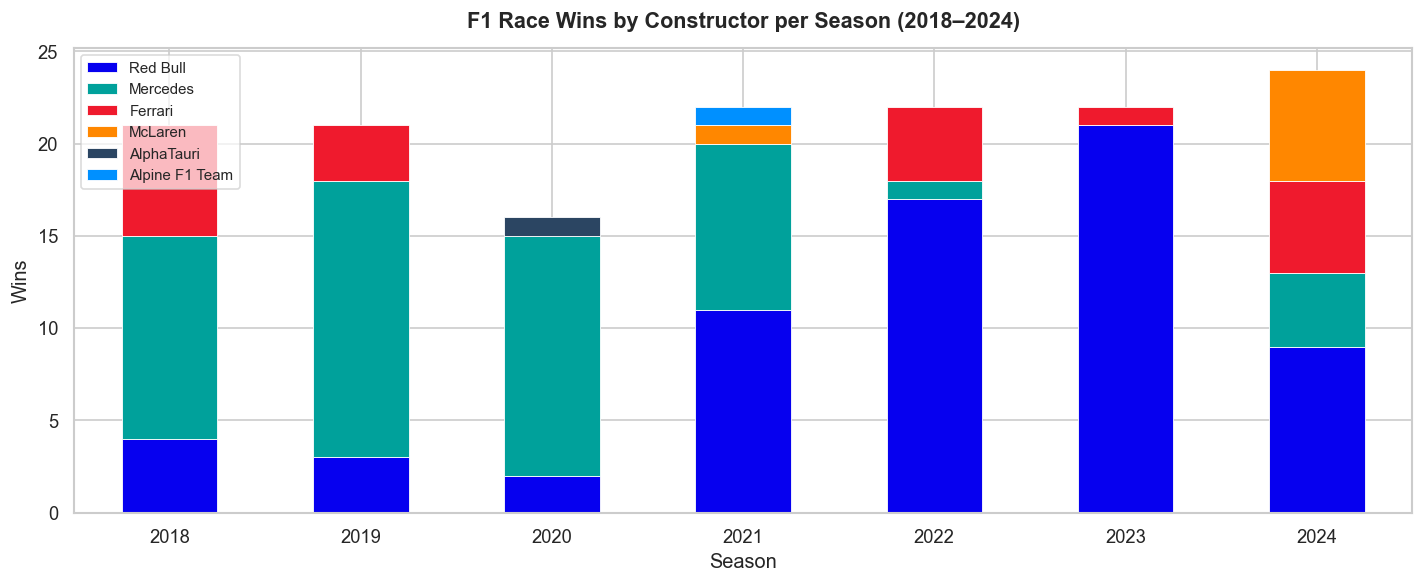

Chart saved.


In [12]:
# Chart 1: Total race wins by constructor per season (stacked bar)
f1_team_colors = {
    'Mercedes': '#00A19B',      # Mercedes Teal
    'Red Bull': '#0600EF',      # Red Bull Dark Blue
    'Ferrari': '#EF1A2D',       # Ferrari Racing Red
    'McLaren': '#FF8700',       # McLaren Papaya Orange
    'Alpine F1 Team': '#0090FF',# Alpine Blue
    'Aston Martin': '#006F62',  # Aston Martin British Racing Green
    'AlphaTauri': '#2B4562',    # AlphaTauri Navy
    'Williams': '#005AFF',      # Williams Blue
}
wins_by_constructor = df[df['win_flag']].groupby(['season','constructor'])['win_flag'].sum().reset_index()
pivot = wins_by_constructor.pivot(index='season', columns='constructor', values='win_flag').fillna(0)

top_constructors = df[df['win_flag']].groupby('constructor')['win_flag'].sum().nlargest(6).index
pivot_top = pivot[top_constructors]

chart_colors = [f1_team_colors.get(team, '#808080') for team in pivot_top.columns]

fig, ax = plt.subplots(figsize=(12, 5))
pivot_top.plot(kind='bar', stacked=True, ax=ax, color=chart_colors, edgecolor='white', linewidth=0.5)
ax.set_title('F1 Race Wins by Constructor per Season (2018–2024)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Season'); ax.set_ylabel('Wins')
ax.set_xticklabels(pivot_top.index, rotation=0)
ax.legend(loc='upper left', fontsize=9, framealpha=0.7)
plt.tight_layout()
plt.savefig('../assets/01_constructor_wins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

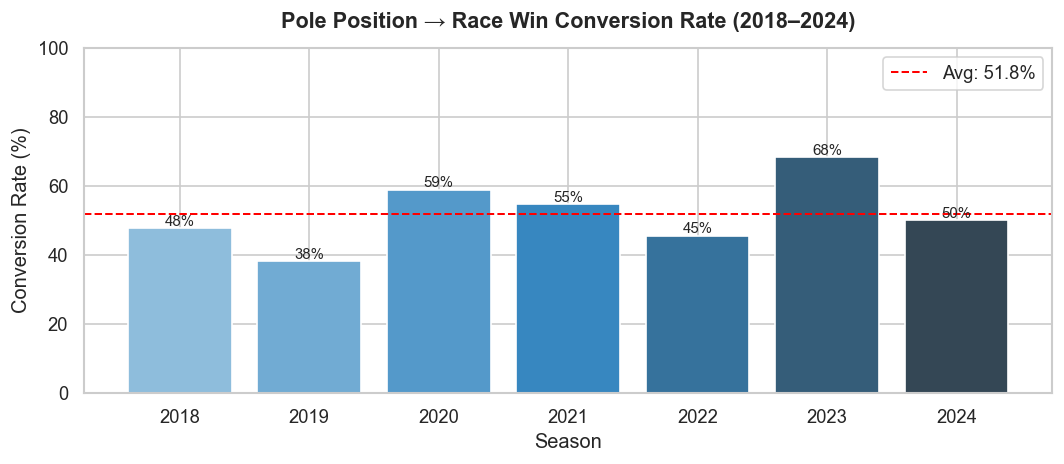

In [7]:
# Chart 2: Pole-to-win conversion rate by season
pole_by_season = df_pole_conv.groupby('season')['pole_converted'].mean().mul(100).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(pole_by_season['season'], pole_by_season['pole_converted'],
              color=sns.color_palette('Blues_d', len(pole_by_season)), edgecolor='white')
ax.axhline(pole_by_season['pole_converted'].mean(), color='red', linestyle='--', linewidth=1.2, label=f"Avg: {pole_by_season['pole_converted'].mean():.1f}%")
for bar, val in zip(bars, pole_by_season['pole_converted']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, f'{val:.0f}%', ha='center', fontsize=9)
ax.set_title('Pole Position → Race Win Conversion Rate (2018–2024)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Season'); ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(0, 100); ax.legend()
plt.tight_layout()
plt.savefig('../assets/02_pole_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

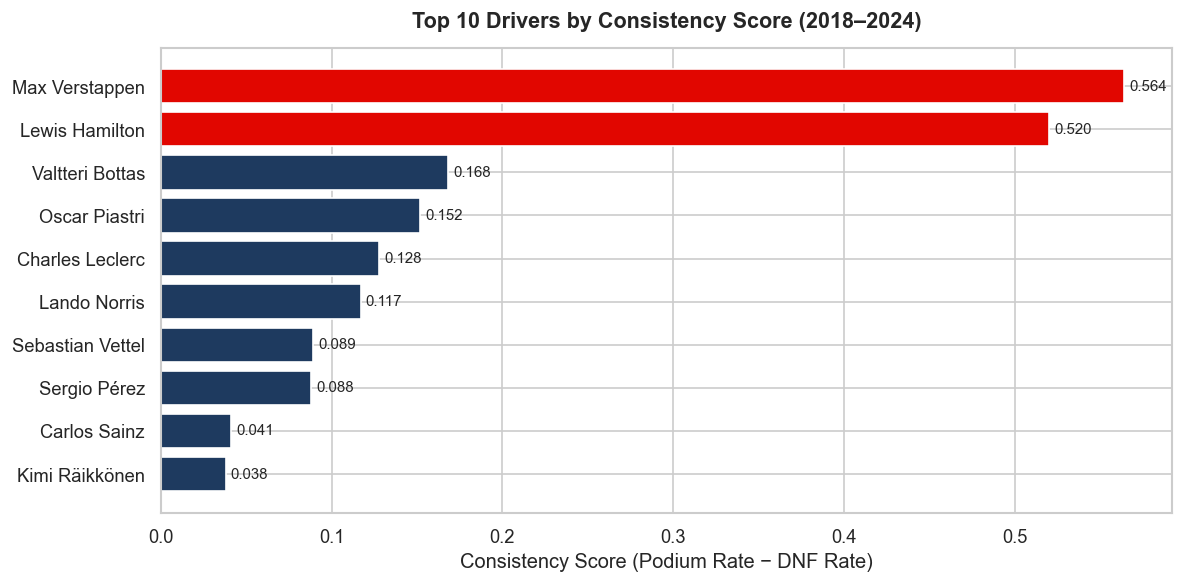

In [8]:
# Chart 3: Top 10 drivers by consistency score (career 2018-2024)
career_stats = driver_season.groupby('driver_name').agg(
    total_races=('races','sum'),
    total_wins=('wins','sum'),
    total_podiums=('podiums','sum'),
    total_dnfs=('dnfs','sum'),
    total_points=('total_points','sum')
).reset_index()
career_stats['consistency_score'] = (
    career_stats['total_podiums'] / career_stats['total_races'] -
    career_stats['total_dnfs'] / career_stats['total_races']
).round(3)

# Filter drivers with at least 20 race starts
career_stats = career_stats[career_stats['total_races'] >= 20]
top10 = career_stats.nlargest(10, 'consistency_score')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E10600' if s > 0.4 else '#1E3A5F' for s in top10['consistency_score']]
bars = ax.barh(top10['driver_name'], top10['consistency_score'], color=colors, edgecolor='white')
ax.set_title('Top 10 Drivers by Consistency Score (2018–2024)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Consistency Score (Podium Rate − DNF Rate)')
ax.invert_yaxis()
for bar, val in zip(bars, top10['consistency_score']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../assets/03_driver_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

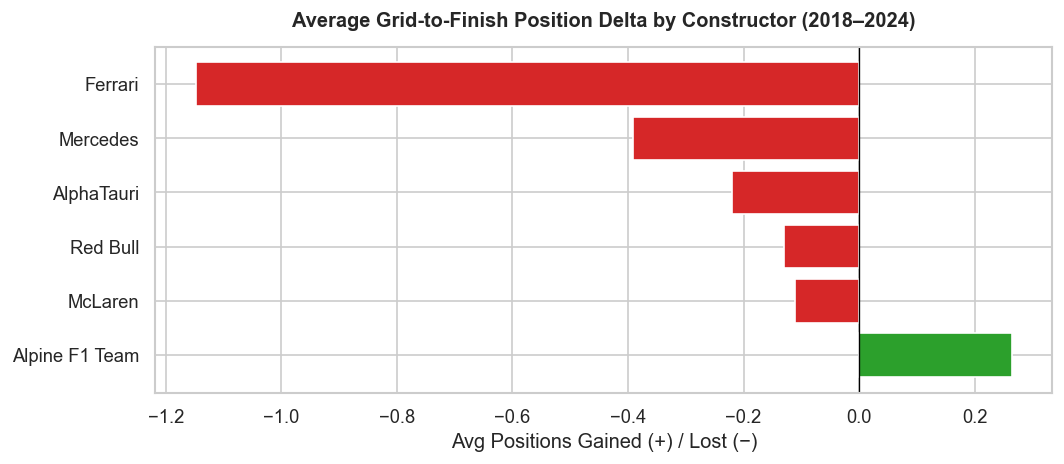

All EDA charts saved to assets/


In [9]:
# Chart 4: Average position gained/lost from grid to finish — top constructors
constructor_delta = df[df['constructor'].isin(top_constructors)].groupby('constructor')['position_delta'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in constructor_delta['position_delta']]
ax.barh(constructor_delta['constructor'], constructor_delta['position_delta'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Average Grid-to-Finish Position Delta by Constructor (2018–2024)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Avg Positions Gained (+) / Lost (−)')
plt.tight_layout()
plt.savefig('../assets/04_position_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('All EDA charts saved to assets/')

## 3. Data Quality Summary

In [10]:
print('=' * 55)
print('CLEANED DATA SUMMARY')
print('=' * 55)
print(f'Seasons:          2018 – 2024 ({df["season"].nunique()} seasons)')
print(f'Total races:      {df["round"].groupby(df["season"]).max().sum()}')
print(f'Unique drivers:   {df["driver_name"].nunique()}')
print(f'Constructors:     {df["constructor"].nunique()}')
print(f'Total race entries: {len(df)}')
print(f'DNF rate:         {df["dnf_flag"].mean()*100:.1f}%')
print(f'Pole conversion:  {overall_rate*100:.1f}% overall')
print('\nFiles ready for SQL analysis in notebook 03.')

CLEANED DATA SUMMARY
Seasons:          2018 – 2024 (7 seasons)
Total races:      149
Unique drivers:   40
Constructors:     16
Total race entries: 2979
DNF rate:         15.3%
Pole conversion:  51.7% overall

Files ready for SQL analysis in notebook 03.
